In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import skew, kurtosis
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import joblib
import os

In [2]:
# META DATA
plot_size = (12, 10)

In [3]:
post_df = pd.read_csv('../../data/Social Media Engagement Dataset.csv')

In [4]:
post_df.columns

Index(['post_id', 'timestamp', 'day_of_week', 'platform', 'user_id',
       'location', 'language', 'text_content', 'hashtags', 'mentions',
       'keywords', 'topic_category', 'sentiment_score', 'sentiment_label',
       'emotion_type', 'toxicity_score', 'likes_count', 'shares_count',
       'comments_count', 'impressions', 'engagement_rate', 'brand_name',
       'product_name', 'campaign_name', 'campaign_phase',
       'user_past_sentiment_avg', 'user_engagement_growth',
       'buzz_change_rate'],
      dtype='object')

# Data Cleaning

In [5]:
post_df.isna().sum()

post_id                       0
timestamp                     0
day_of_week                   0
platform                      0
user_id                       0
location                      0
language                      0
text_content                  0
hashtags                      0
mentions                   3941
keywords                      0
topic_category                0
sentiment_score               0
sentiment_label               0
emotion_type                  0
toxicity_score                0
likes_count                   0
shares_count                  0
comments_count                0
impressions                   0
engagement_rate               0
brand_name                    0
product_name                  0
campaign_name                 0
campaign_phase                0
user_past_sentiment_avg       0
user_engagement_growth        0
buzz_change_rate              0
dtype: int64

We can see that most of the data is clean despite 3941 records having no mentions, which is acceptable noting that some posts may not have mentions at all

## Data Exploration & Checking Anomalies in dataset

In [6]:
print(f'Number of records {post_df.shape[0]}')
print(f'Number of attributes {post_df.shape[1]}')

Number of records 12000
Number of attributes 28


In [7]:
post_df.nunique()

post_id                    12000
timestamp                  11997
day_of_week                    7
platform                       5
user_id                    12000
location                      33
language                      10
text_content               11997
hashtags                    4490
mentions                     225
keywords                    9342
topic_category                 6
sentiment_score             9038
sentiment_label                3
emotion_type                   5
toxicity_score              6987
likes_count                 4553
shares_count                1994
comments_count              1001
impressions                11279
engagement_rate             9363
brand_name                    10
product_name                  70
campaign_name                 23
campaign_phase                 3
user_past_sentiment_avg     9050
user_engagement_growth      6966
buzz_change_rate            1997
dtype: int64

As seen above, there are 12000 records in the dataset, each containing a specific and unique post_id which assures as no duplicates are in the dataset. However, we also realise that there also exists the same amount of user_id as post_id, meaning likely that the synthetic data designed a single post per user.

In [8]:
def get_numeric_cols(df):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    if not numeric_cols:
        print("There are no numeric columns")
        return None
    return numeric_cols

def get_categorical_cols(df):
    categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
    if not categorical_cols:
        print("There are no categorical columns")
        return None
    return categorical_cols

In [9]:
post_df.describe()

,sentiment_score,toxicity_score,likes_count,shares_count,comments_count,impressions,engagement_rate,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
count,12000.000000,12000.000000,12000.00000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,0.000553,0.503868,2490.72025,1007.167167,504.34575,49811.338500,0.278137,0.001472,0.000998,0.729692
std,0.583563,0.288198,1441.53253,575.072282,288.68416,28930.289451,1.149206,0.576627,0.289940,57.787219
min,-0.999800,0.000000,0.00000,0.000000,0.00000,130.000000,0.001880,-0.999600,-0.499900,-99.900000
25%,-0.503200,0.251400,1236.00000,510.000000,253.00000,24716.500000,0.049100,-0.495975,-0.248400,-48.700000
50%,-0.006200,0.505950,2496.00000,1018.000000,503.00000,49674.000000,0.080605,0.001950,0.002800,0.900000
75%,0.513525,0.756200,3723.25000,1501.000000,755.00000,74815.000000,0.163123,0.501725,0.250700,50.100000
max,0.999900,0.999900,5000.00000,2000.000000,1000.00000,99997.000000,32.211710,0.999400,0.499900,99.900000


In [10]:
# Function used to extract statistical information about numeric data
def get_statistical_profile(df):
    numeric_cols = get_numeric_cols(df)
    stat_list = []

    for col in numeric_cols:
        stats = {
            'Column': col,
            'Mean': df[col].mean(),
            'Median': df[col].median(),
            'Mode': df[col].mode()[0],
            'Std Dev': df[col].std(),
            'Variance': df[col].var(),
            'IQR': df[col].quantile(0.75) - df[col].quantile(0.25),
            'Skewness':skew(df[col].dropna()),
            'Kurtosis': kurtosis(df[col].dropna())
        }
        stat_list.append(stats)
    return pd.DataFrame(stat_list)

get_statistical_profile(post_df)

,Column,Mean,Median,Mode,Std Dev,Variance,IQR,Skewness,Kurtosis
0,sentiment_score,0.000553,-0.006200,-0.3636,0.583563,3.405459e-01,1.016725,0.003397,-1.226232
1,toxicity_score,0.503868,0.505950,0.5536,0.288198,8.305804e-02,0.504800,-0.010372,-1.217820
2,likes_count,2490.720250,2496.000000,3008.0000,1441.532530,2.078016e+06,2487.250000,0.008636,-1.197601
3,shares_count,1007.167167,1018.000000,612.0000,575.072282,3.307081e+05,991.000000,-0.013608,-1.191616
4,comments_count,504.345750,503.000000,465.0000,288.684160,8.333854e+04,502.000000,-0.015402,-1.210992
5,impressions,49811.338500,49674.000000,6623.0000,28930.289451,8.369616e+08,50098.500000,0.006081,-1.198300
6,engagement_rate,0.278137,0.080605,0.0498,1.149206,1.320673e+00,0.114022,13.955317,259.251177
7,user_past_sentiment_avg,0.001472,0.001950,-0.1901,0.576627,3.324989e-01,0.997700,-0.011579,-1.201459
8,user_engagement_growth,0.000998,0.002800,-0.0641,0.289940,8.406499e-02,0.499100,-0.009274,-1.205249
9,buzz_change_rate,0.729692,0.900000,-13.3000,57.787219,3.339363e+03,98.800000,-0.013982,-1.193415


Here we can see statistical data about the numerical values, specifically for engagement_rate user_engagement-growth and buzz_change_rate columns. Most of the data show a near perfectly normally distributed data except for engagement_rate column which has a right skeweness. The shape of the distribution of the columns mostly show a Playkurtic shape (Kurtosis < 3) which means that most of these columns have a thin tail and flat peak distributions with fewer outliers.

However, it is also important to point out that in the describe() function used in the previous block shows that the engagement_rate column having a maximum value of ~32 despite the mean and IQR being at around ~0.27 and ~0.11 respectively. This means that the data contains inconsistencies and potential outliers. Despite it being synthetic data generated, the developers will take the necessary practical measures to remove inconsistencies and outliers from the dataset. The Kurtosis of the engagement_rate column shows an exceeding value of ~259, which indicates a Leptokurtic shape (Kurtosis > 3), depicting a thick tail and high peak distributions with a high number of outliers.

Further to this, we can also see that on average, people are more likely to share a post than to comment on it, striking an unexpected result (as seen on average). The likes, comments and shares on posts pose a much broader range of values whereby the mode is significantly further than the median and mode per each of columns. 


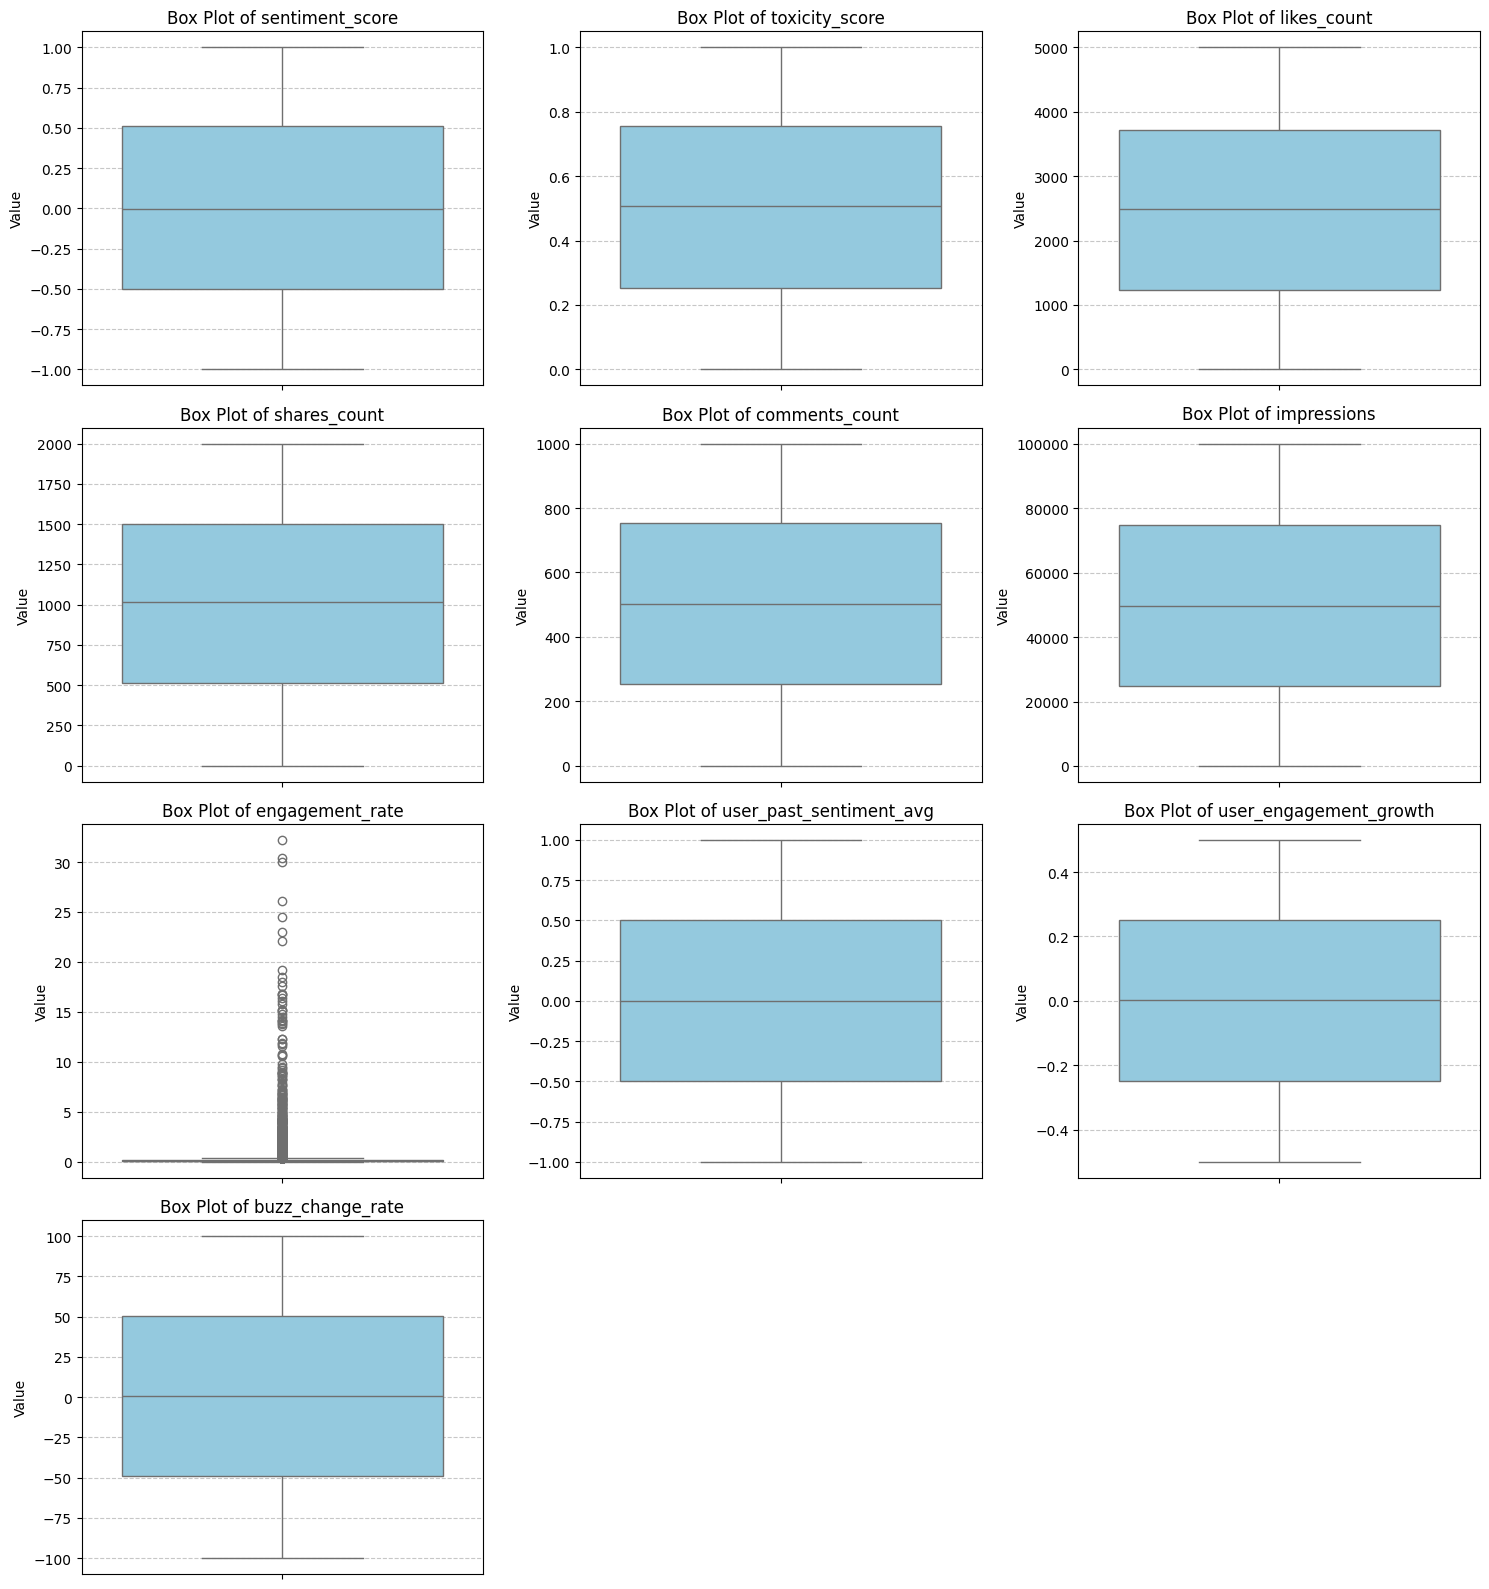

In [11]:
def plot_numeric_values_box_plot(df, cols_per_row=3):
    numeric_cols = get_numeric_cols(df)
    
    # Calculating grid dimensions
    num_plots = len(numeric_cols)
    num_rows = math.ceil(num_plots / cols_per_row)

    plt.figure(figsize=(cols_per_row*5, num_rows*4))

    for i, col in enumerate(numeric_cols):
        plt.subplot(num_rows, cols_per_row, i + 1)
        sns.boxplot(y=df[col], color='skyblue')
        plt.title(f'Box Plot of {col}')
        plt.ylabel('Value')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
  
plot_numeric_values_box_plot(post_df)

Here we see most of the columns described through the box plot using the matplotlib library as having no outliers except for the engagement_rate column. As was the concern of the developers previously, we know have a visual proof of the concern of potential outliers in the engagement_rate column. Therefore, the developers will use the IQR clipping method to remove outliers in the dataset.

The developers have decided to use the Z-score method to clamp extreme outliers that are significantly far from the mean. Instead of using a more robust solution such as the IQR method, which can ignore extreme values, using the Z-score is much more preferable since the developers will assume the synthetic data generated from an LLM or an agent hallucinated, thereby making extreme data undesirable.

In [12]:
def clip_outliers(df, columns=['engagement_rate'], threshold=3): # Using 3 Standard Deviations for threshold
    df = df.copy()

    for col in columns:
        if col in df.columns:
            mu = df[col].mean()
            sigma = df[col].std()

            upper_bound = mu + threshold * sigma
            lower_bound = mu - threshold * sigma

            df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

cleaned_post_df = clip_outliers(post_df)

In [13]:
get_statistical_profile(cleaned_post_df)

,Column,Mean,Median,Mode,Std Dev,Variance,IQR,Skewness,Kurtosis
0,sentiment_score,0.000553,-0.006200,-0.363600,0.583563,3.405459e-01,1.016725,0.003397,-1.226232
1,toxicity_score,0.503868,0.505950,0.553600,0.288198,8.305804e-02,0.504800,-0.010372,-1.217820
2,likes_count,2490.720250,2496.000000,3008.000000,1441.532530,2.078016e+06,2487.250000,0.008636,-1.197601
3,shares_count,1007.167167,1018.000000,612.000000,575.072282,3.307081e+05,991.000000,-0.013608,-1.191616
4,comments_count,504.345750,503.000000,465.000000,288.684160,8.333854e+04,502.000000,-0.015402,-1.210992
5,impressions,49811.338500,49674.000000,6623.000000,28930.289451,8.369616e+08,50098.500000,0.006081,-1.198300
6,engagement_rate,0.222047,0.080605,3.725754,0.505856,2.558900e-01,0.114022,5.219653,29.834241
7,user_past_sentiment_avg,0.001472,0.001950,-0.190100,0.576627,3.324989e-01,0.997700,-0.011579,-1.201459
8,user_engagement_growth,0.000998,0.002800,-0.064100,0.289940,8.406499e-02,0.499100,-0.009274,-1.205249
9,buzz_change_rate,0.729692,0.900000,-13.300000,57.787219,3.339363e+03,98.800000,-0.013982,-1.193415


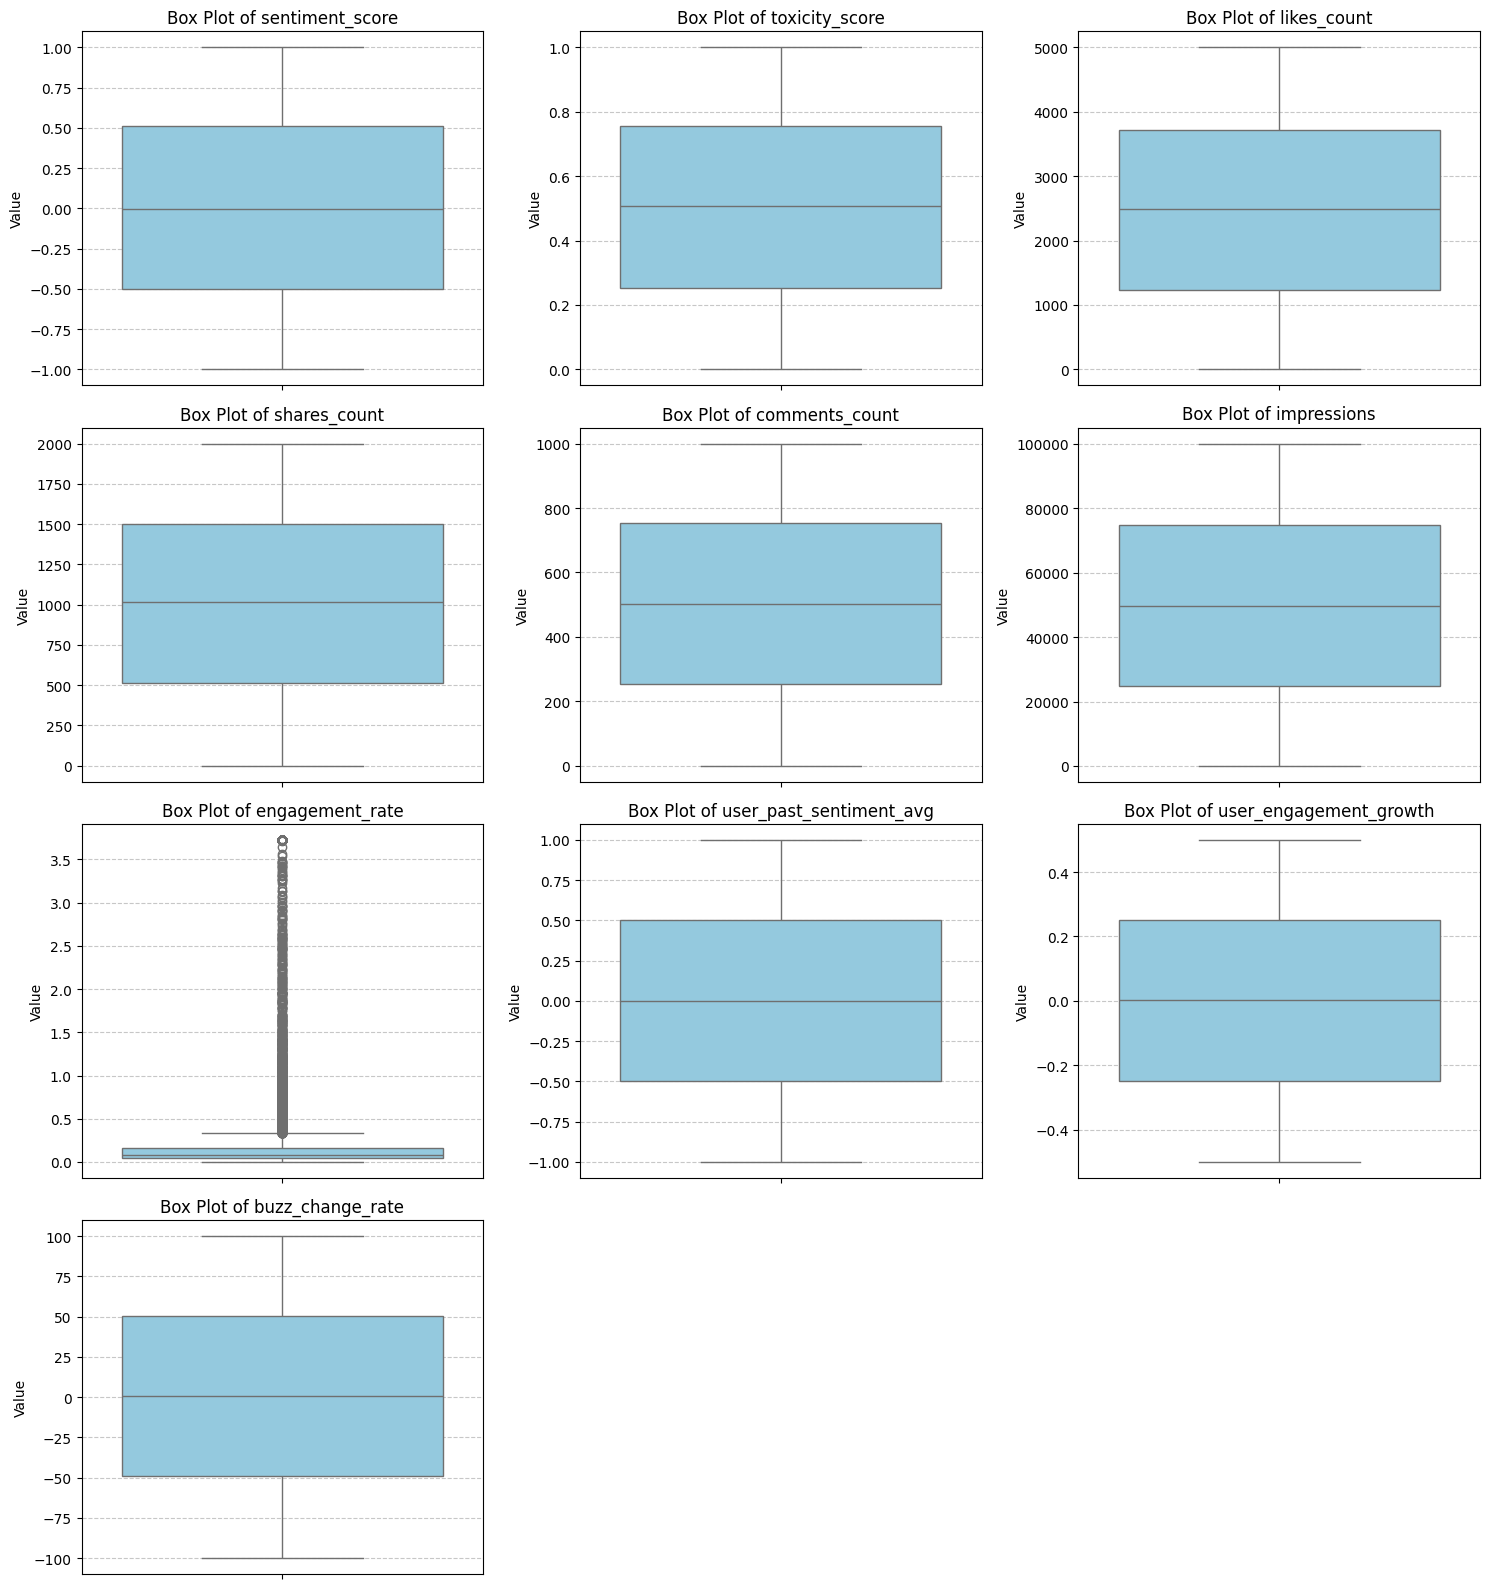

In [14]:
plot_numeric_values_box_plot(cleaned_post_df)

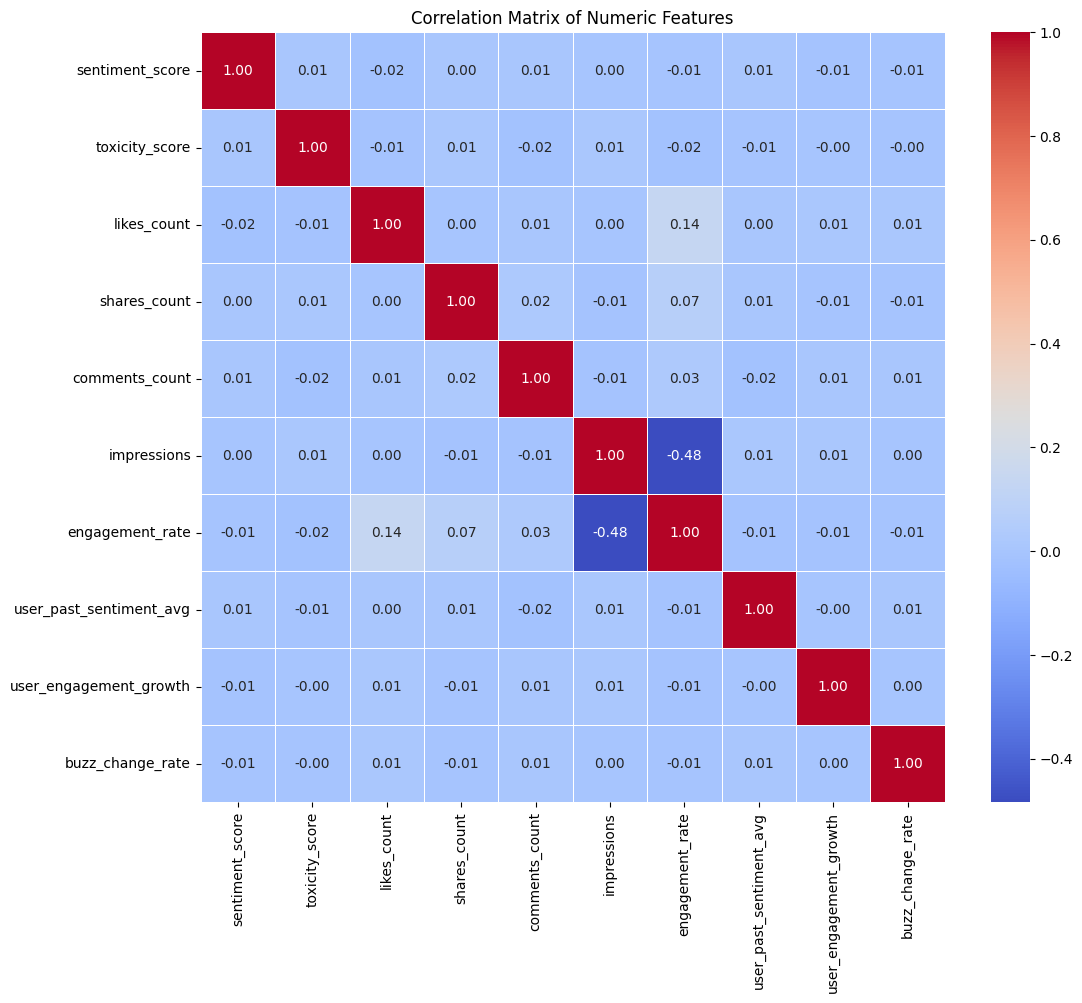

In [15]:
def plot_correlation_matrix(df):
    subset = df[get_numeric_cols(df)]
    
    corr = subset.corr()

    plt.figure(figsize=plot_size)
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Matrix of Numeric Features')
    plt.show()

plot_correlation_matrix(cleaned_post_df)

The correlation matrix gives us a very good understanding of linear relationship between numeric variables. From the plot above, we can see that no attribute share a linear relationship between one another, save for impressions and engagement_rate with a weak negative correlation. However, this proves to of no use for building a linear model. Therefore, the developers will not opt to use linear regression.

In [16]:
cleaned_post_df['timestamp']

0        2024-12-09 11:26:15
1        2024-07-28 19:59:26
2        2024-11-23 14:00:12
3        2024-09-16 04:35:25
4        2024-09-05 21:03:01
                ...         
11995    2025-01-10 07:55:51
11996    2024-12-04 18:50:38
11997    2024-10-24 19:11:24
11998    2024-11-12 03:07:19
11999    2024-05-15 20:07:23
Name: timestamp, Length: 12000, dtype: object

In [17]:
cleaned_post_df.columns

Index(['post_id', 'timestamp', 'day_of_week', 'platform', 'user_id',
       'location', 'language', 'text_content', 'hashtags', 'mentions',
       'keywords', 'topic_category', 'sentiment_score', 'sentiment_label',
       'emotion_type', 'toxicity_score', 'likes_count', 'shares_count',
       'comments_count', 'impressions', 'engagement_rate', 'brand_name',
       'product_name', 'campaign_name', 'campaign_phase',
       'user_past_sentiment_avg', 'user_engagement_growth',
       'buzz_change_rate'],
      dtype='object')

# Visualizations

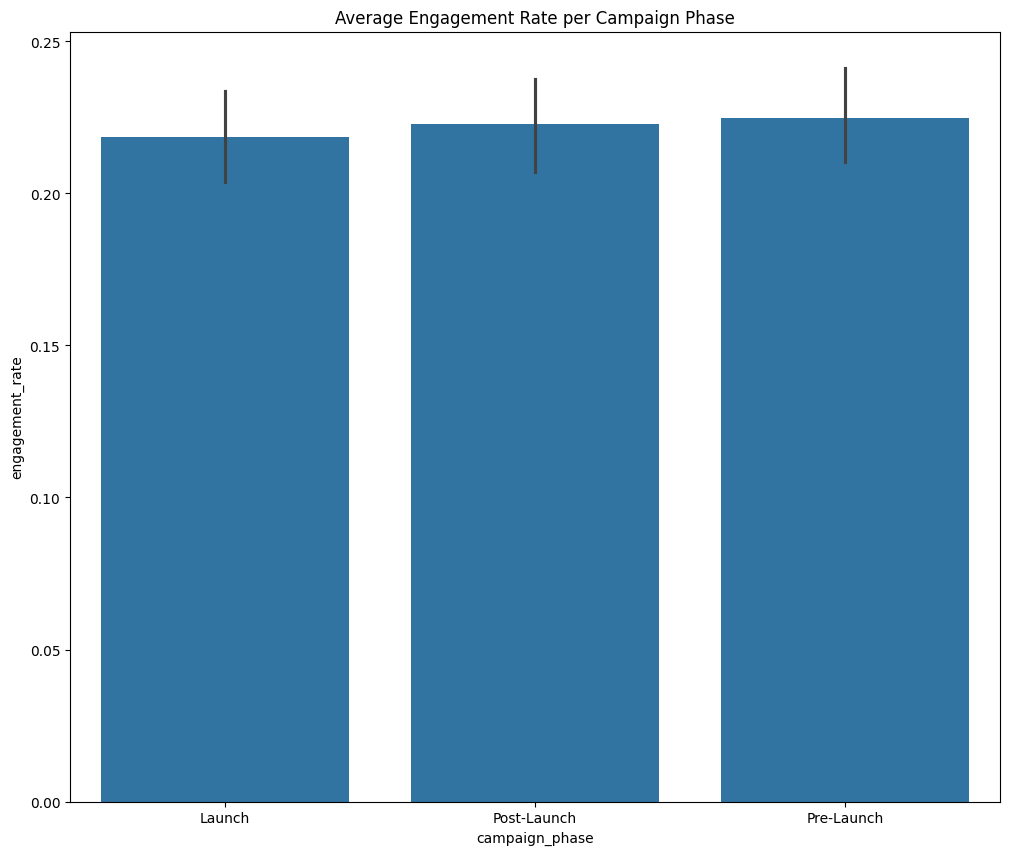

In [18]:
plt.figure(figsize=plot_size)
sns.barplot(data=cleaned_post_df, x='campaign_phase', y='engagement_rate', estimator='mean')
plt.title('Average Engagement Rate per Campaign Phase')
plt.show()

The developers studied the relationship between engagement_rate and campaign phase, whereby the average engagment_rate per campaign phase was captured. The data shows that post and pre launch campaign phase have a slightly higher engagement rate on average than launch phase.

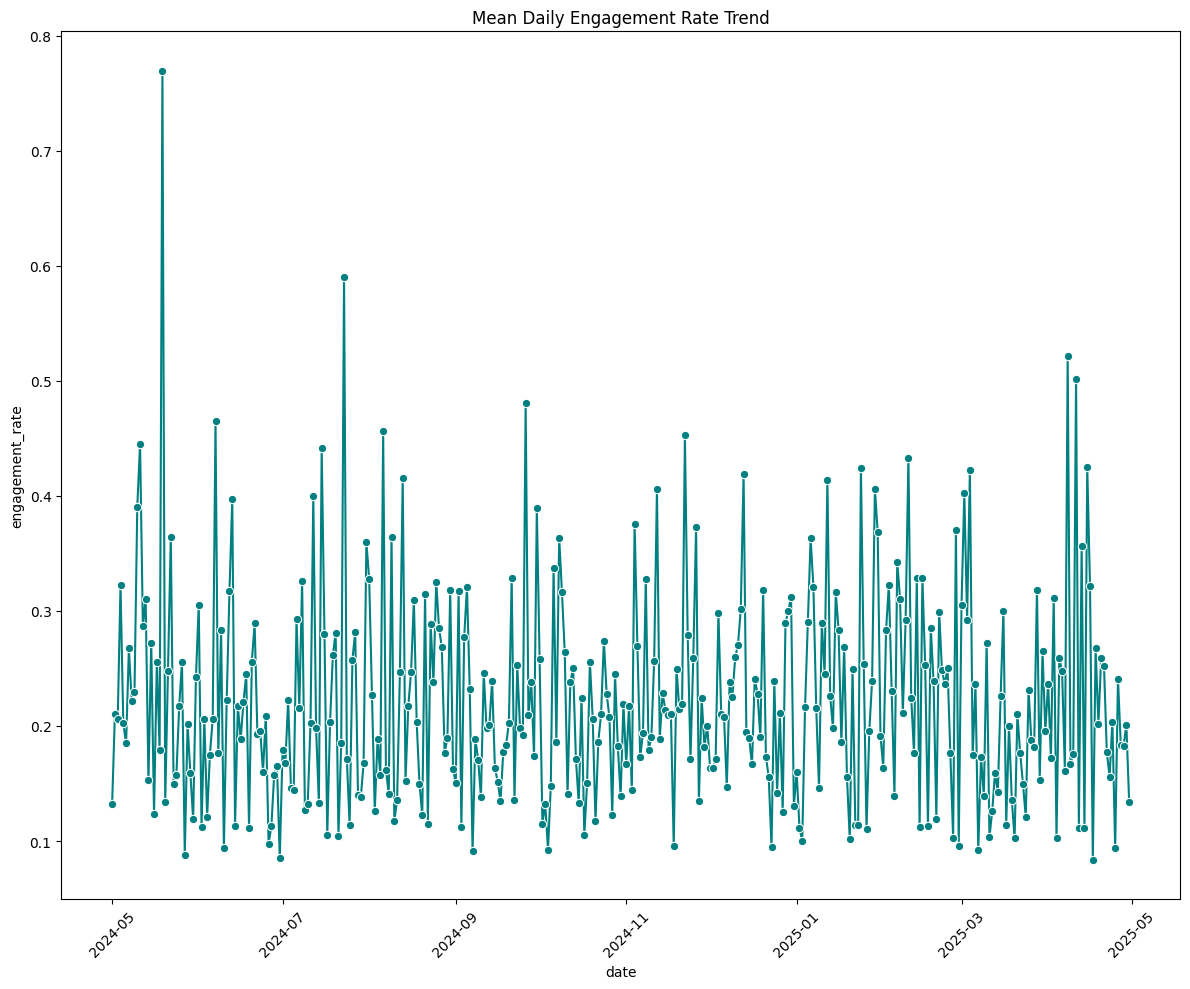

In [19]:
plt.figure(figsize=plot_size)
cleaned_post_df['date'] = pd.to_datetime(cleaned_post_df['timestamp']).dt.date
df_daily = cleaned_post_df.groupby('date')['engagement_rate'].mean().reset_index()
sns.lineplot(data=df_daily, x='date', y='engagement_rate', marker='o', color='teal')
plt.xticks(rotation=45)
plt.title('Mean Daily Engagement Rate Trend')
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_16064\631170536.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_post_df, x='sentiment_label', palette='viridis', order=['Positive', 'Neutral', 'Negative'])


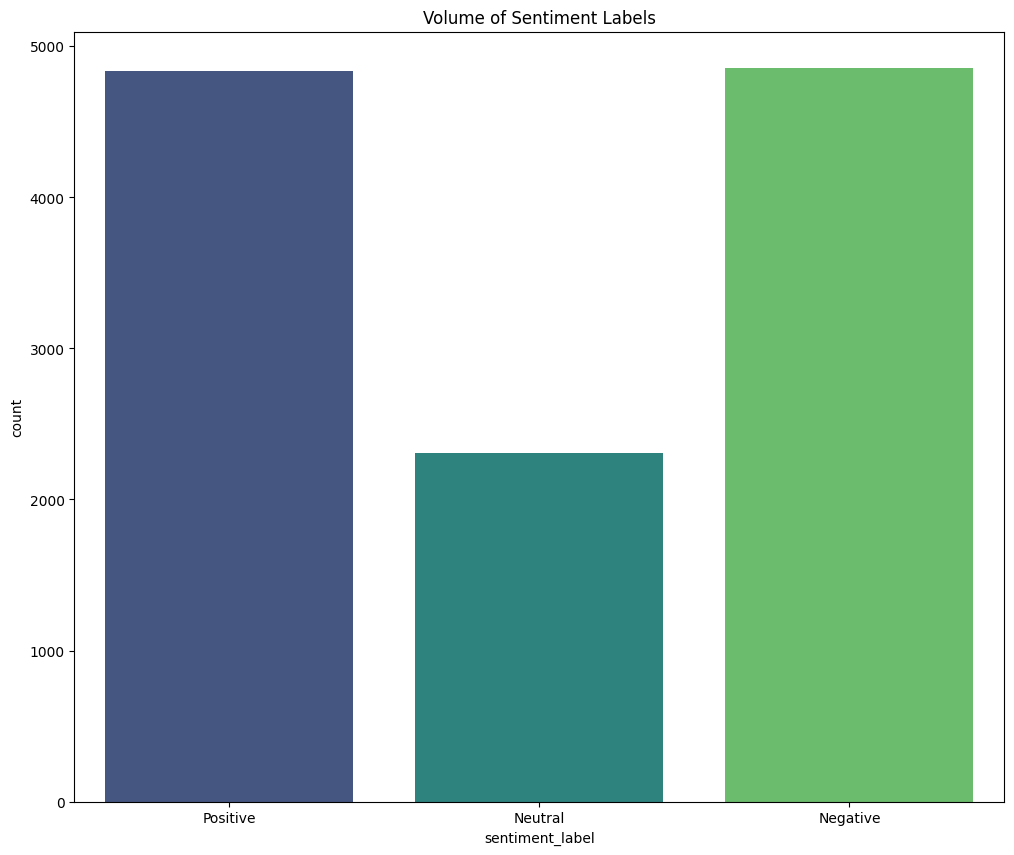

In [20]:
plt.figure(figsize=plot_size)
sns.countplot(data=cleaned_post_df, x='sentiment_label', palette='viridis', order=['Positive', 'Neutral', 'Negative'])
plt.title('Volume of Sentiment Labels')
plt.show()

In [21]:
# Dropping post_id, timestamp, day of week, user_id, text_content, hashtags, mentions, keywords, date
cleaned_post_df = cleaned_post_df.drop(columns=
                                       ['post_id', 'timestamp', 'day_of_week', 'user_id', 
                                        'text_content', 'hashtags', 'mentions', 'keywords', 'date'
                                        ])

In [22]:
def capture_mi_scores(df, target_col='engagement_rate'):
    # 1. Drop the target from the features list and handle NaNs
    df = df.copy().dropna(subset=[target_col])
    X = df.drop(columns=[target_col])
    y = df[target_col]

    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

    X_encoded = X.copy()
    for col in categorical_cols:
        X_encoded[col], _ = X_encoded[col].factorize()

    mi_categorical = mutual_info_regression(
        X_encoded[categorical_cols], y, discrete_features=True, random_state=42
    )

    mi_numeric = mutual_info_regression(
        X_encoded[numeric_cols], y, discrete_features=False, random_state=42
    )

    return {
        'categorical_features': dict(zip(categorical_cols, mi_categorical)),
        'numeric_features': dict(zip(numeric_cols, mi_numeric))
    }

mi_results = capture_mi_scores(cleaned_post_df)

print("--- Categorical MI Scores ---")
for feature, score in sorted(mi_results['categorical_features'].items(), key=lambda x: x[1], reverse=True):
    print(f"{feature}: {score:.4f}")

print("\n--- Numeric MI Scores ---")
for feature, score in sorted(mi_results['numeric_features'].items(), key=lambda x: x[1], reverse=True):
    print(f"{feature}: {score:.4f}")

--- Categorical MI Scores ---
emotion_type: 0.0104
language: 0.0093
campaign_phase: 0.0078
brand_name: 0.0046
platform: 0.0000
location: 0.0000
topic_category: 0.0000
sentiment_label: 0.0000
product_name: 0.0000
campaign_name: 0.0000

--- Numeric MI Scores ---
impressions: 0.8488
likes_count: 0.2242
shares_count: 0.0415
comments_count: 0.0098
buzz_change_rate: 0.0067
toxicity_score: 0.0042
sentiment_score: 0.0036
user_past_sentiment_avg: 0.0000
user_engagement_growth: 0.0000


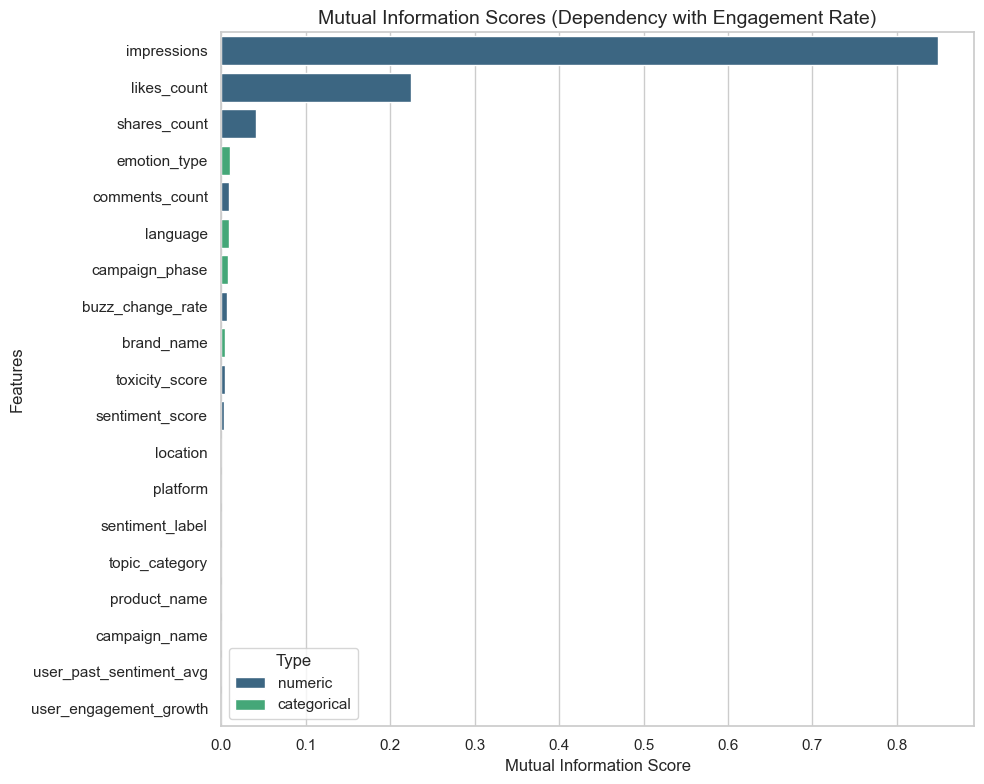

In [23]:
def plot_mi_scores(mi_results):
    mi_data = []
    for group, features in mi_results.items():
        for feature, score in features.items():
            mi_data.append({'Feature': feature, 'MI Score': score, 'Type': group.split('_')[0]})
    
    df_plot = pd.DataFrame(mi_data).sort_values(by='MI Score', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.set_theme(style="whitegrid")
    
    ax = sns.barplot(
        data=df_plot, 
        y='Feature', 
        x='MI Score', 
        hue='Type', 
        palette='viridis'
    )
    
    plt.title('Mutual Information Scores (Dependency with Engagement Rate)', fontsize=14)
    plt.xlabel('Mutual Information Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_mi_scores(mi_results)

MI or Mutual Information, measures the dependency between 2 variables. This is unlike correlation, it does not care if the relationship is linear.

From the results shown above, we see that impressions has an extremely high score with respect to engagement_rate. likes_count also shows a solid, meaningful relationship and suggests that the likes are the strong driver of engagement rate among the interaction metrics.

Surprisingly, shares and comments counts both have a very weak relationship with engagement_rate.

To sum up, the developers have considered to capture the needed features for the dataset given the following:
MI Score (0.5 - 1.0): Keep as primary feature but need to consider data leakage
MI Score (0.1 - 0.5): Engagement drivers
MI Score (0.01 - 0.1): Will still include as subsidary features
MI Score (< 0.01): Will consider dropping

# Model Training & Prediction

As we have seen in the exploration stage, the data does not consider a time-series pattern for a specific post but instead follows a post-by-post performance records. Therefore, conisdering using LSTM for this type of data is not optimal. Furthermore, we have also discussed that there exists no linear relationship between the attributes and the target. In conclusion, the developers will consider using a non-linear prediction algorithm such as XGBoost, Random Forest, Decision Tree or SVM.

In [24]:
X = cleaned_post_df.drop(columns=
                         ['user_past_sentiment_avg', 'user_engagement_growth', 'brand_name',
                          'platform', 'location', 'topic_category', 
                          'sentiment_label', 'product_name', 'campaign_name',
                          'toxicity_score', 'sentiment_score'])
y = cleaned_post_df['engagement_rate']

In [25]:
categorical_cols = get_categorical_cols(X)

X_encoded = X.copy()

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

X = X_encoded

In [1]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

NameError: name 'train_test_split' is not defined

In [27]:
print("Columns in X:")
print(X.columns.tolist())

print("\nData types in X:")
print(X.dtypes)

print("\nLooking for non-numeric columns...")

Columns in X:
['language', 'emotion_type', 'likes_count', 'shares_count', 'comments_count', 'impressions', 'engagement_rate', 'campaign_phase', 'buzz_change_rate']

Data types in X:
language              int64
emotion_type          int64
likes_count           int64
shares_count          int64
comments_count        int64
impressions           int64
engagement_rate     float64
campaign_phase        int64
buzz_change_rate    float64
dtype: object

Looking for non-numeric columns...


The developers considered using a train_test_split() function with a random state since there exists no time-series connection. Instead, the developers will use a train split of 80-20 as per the standard.

In [28]:
model_params = {
    'decision_tree': {
        'model': DecisionTreeRegressor(),
        'params': {
            'max_depth': [None, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'random_forest': {
        'model': RandomForestRegressor(),
        'params': {
            'n_estimators': [50, 100],
            'max_features': ['sqrt', 'log2'],
            'max_depth': [None, 10]
        }
    },
    # 'svm_regressor': {
    #     'model': SVR(),
    #     'params': {
    #         'C': [0.1, 1, 10],
    #         'kernel': ['linear', 'rbf'],
    #         'epsilon': [0.1, 0.2, 0.5]
    #     }
    # },
    'xgboost_regressor': {
        'model': XGBRegressor(objective='reg:squarederror'),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5]
        }
    }
}

Note: SVM was discarded since the model took a very long time to train.

# Training, Testing, Saving and Exporting the best model

In [36]:
test_results = []

if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

for model_name, mp in model_params.items():
    print(f"Evaluating best {model_name} on test data...")
    
    best_model = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='r2').fit(X_train, y_train).best_estimator_
    
    y_pred = best_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Exporting model
    filename = f"saved_models/best_{model_name}_model.pkl"
    joblib.dump(best_model, filename)
    print(f"Successfully saved to {filename}")

    # Saving results to list
    test_results.append({
        'Model': model_name,
        'Test MAE': round(mae, 4),
        'Test RMSE': round(rmse, 4),
        'Test R2': round(r2, 4)
    })

print("All Models have been exported")

Evaluating best decision_tree on test data...
Successfully saved to saved_models/best_decision_tree_model.pkl
Evaluating best random_forest on test data...
Successfully saved to saved_models/best_random_forest_model.pkl
Evaluating best xgboost_regressor on test data...
Successfully saved to saved_models/best_xgboost_regressor_model.pkl
All Models have been exported


In [ ]:
df_test_comparison = pd.DataFrame(test_results)
print("\n--- Final Test Set Performance ---")
print(df_test_comparison.sort_values(by='Test MAE'))


--- Final Test Set Performance ---
               Model  Test MAE  Test RMSE  Test R2
0      decision_tree    0.0004     0.0026   1.0000
2  xgboost_regressor    0.0052     0.0315   0.9962
1      random_forest    0.0081     0.0218   0.9982


We see that the performance is tremendously excellent using a the decision tree model with an R2 Score of 1 (perfect score). Despite the suspicion behind its performance, we must consider that the data is synthetic (likely generated from an LLM) and does not pertain actual, real social media data. Therefore, the results can be considered reasonable within these realms of scores.

# Demo Results

In [51]:
no_records_to_test = 15
np.random.seed(42)
random_indices = np.random.choice(len(X_test), size=no_records_to_test, replace=False)
sample_X = X_test.iloc[random_indices]
sample_y = y_test.iloc[random_indices]

# Get the 75th percentile of enagement_rate
trend_threshold = y.quantile(0.75)

model_files = {
    'Decision Tree': 'saved_models/best_decision_tree_model.pkl',
    'Random Forest': 'saved_models/best_random_forest_model.pkl',
    'XGBoost': 'saved_models/best_xgboost_regressor_model.pkl'
}

results_df = pd.DataFrame({'Actual Value': sample_y})

for model_name, file_path in model_files.items():
    try:
        trend_prediction = []
        model = joblib.load(file_path)
        predictions = model.predict(sample_X)
        results_df[f'{model_name} Prediction (Engament Rate)'] = predictions.round(4)
        for prediction in predictions:
            if prediction < trend_threshold:
                trend_prediction.append('Not Trend')
            else:
                trend_prediction.append('Trend')
        
        results_df[f'{model_name} Prediction (Trend or Not Trend)'] = trend_prediction
    
    except FileNotFoundError:
        print(f"Warning: {file_path} not found")

In [54]:
print("=== 15 Random Samples Comparison ===")
print(f"75th Percentile Engagement Rate: {trend_threshold.round(4)}")
results_df.head(no_records_to_test)


=== 15 Random Samples Comparison ===
75th Percentile Engagement Rate: 0.1631


,Actual Value,Decision Tree Prediction (Engament Rate),Decision Tree Prediction (Trend or Not Trend),Random Forest Prediction (Engament Rate),Random Forest Prediction (Trend or Not Trend),XGBoost Prediction (Engament Rate),XGBoost Prediction (Trend or Not Trend)
2390,0.54827,0.5484,Trend,0.5512,Trend,0.5313,Trend
9736,0.06258,0.0626,Not Trend,0.0622,Not Trend,0.0632,Not Trend
1479,0.06284,0.0628,Not Trend,0.0631,Not Trend,0.0632,Not Trend
1107,0.15087,0.1506,Not Trend,0.1502,Not Trend,0.1500,Not Trend
10581,0.11822,0.1182,Not Trend,0.1192,Not Trend,0.1196,Not Trend
4367,0.02975,0.0297,Not Trend,0.0301,Not Trend,0.0307,Not Trend
6486,0.08629,0.0863,Not Trend,0.0876,Not Trend,0.0855,Not Trend
6025,0.09470,0.0948,Not Trend,0.0946,Not Trend,0.0946,Not Trend
7677,0.05165,0.0516,Not Trend,0.0522,Not Trend,0.0519,Not Trend
958,0.04283,0.0428,Not Trend,0.0434,Not Trend,0.0416,Not Trend
